# Проект: Исследование объявлений о продаже квартир.

**Цель исследования:**

 - Установить параметры, влияющие на цену объектов.
 - Определять рыночную стоимость объектов недвижимости.

В дальнейшем это поможет построить автоматизированную систему, которая будет отслеживать аномалии и мошенническую деятельность.

**Данные для исследования:**

Архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет из сервиса Яндекс Недвижимость. 

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. В том числе, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

**Описание данных:**
 - airports_nearest — расстояние до ближайшего аэропорта в метрах (м)
 - balcony — число балконов
 - ceiling_height — высота потолков (м)
 - cityCenters_nearest — расстояние до центра города (м)
 - days_exposition — сколько дней было размещено объявление (от публикации до снятия)
 - first_day_exposition — дата публикации
 - floor — этаж
 - floors_total — всего этажей в доме
 - is_apartment — апартаменты (булев тип)
 - kitchen_area — площадь кухни в квадратных метрах (м²)
 - last_price — цена на момент снятия с публикации
 - living_area — жилая площадь в квадратных метрах (м²)
 - locality_name — название населённого пункта
 - open_plan — свободная планировка (булев тип)
 - parks_around3000 — число парков в радиусе 3 км
 - parks_nearest — расстояние до ближайшего парка (м)
 - ponds_around3000 — число водоёмов в радиусе 3 км
 - ponds_nearest — расстояние до ближайшего водоёма (м)
 - rooms — число комнат
 - studio — квартира-студия (булев тип)
 - total_area — общая площадь квартиры в квадратных метрах (м²)
 - total_images — число фотографий квартиры в объявлении

### Чтение данных и изучение общей информации

In [1]:
# Импорт библиотеки pandas.
# Чтение файла с данными и сохранение в датафрейм
import pandas as pd
data = pd.read_csv('*****')
data.head()

,total_images\tlast_price\ttotal_area\tfirst_day_exposition\trooms\tceiling_height\tfloors_total\tliving_area\tfloor\tis_apartment\tstudio\topen_plan\tkitchen_area\tbalcony\tlocality_name\tairports_nearest\tcityCenters_nearest\tparks_around3000\tparks_nearest\tponds_around3000\tponds_nearest\tdays_exposition
0,20\t13000000.0\t108.0\t2019-03-07T00:00:00\t3\...
1,7\t3350000.0\t40.4\t2018-12-04T00:00:00\t1\t\t...
2,10\t5196000.0\t56.0\t2015-08-20T00:00:00\t2\t\...
3,0\t64900000.0\t159.0\t2015-07-24T00:00:00\t3\t...
4,2\t10000000.0\t100.0\t2018-06-19T00:00:00\t2\t...


In [2]:
# Чтение файла с данными и сохранение в датафрейм, с учетом разделителя.
data = pd.read_csv('/datasets/real_estate_data.csv',sep = '\t')
# Вывод на экран первые 10 строк.
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


In [3]:
# Вывод основной информации о датафреме.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

In [4]:
# Расчет кол-ва строк в изначальном датафрейм
data_total = len(data)
data_total

23699

**При анализе общей информации выявлены столбцы с пропусками, которые необходимо заполнить:**

    
    - ceiling_height
    - floors_total
    - living_area
    - is_apartment
    - kitchen_area
    - balcony
    - locality_name
    - airports_nearest
    - cityCenters_nearest
    - parks_around3000
    - parks_nearest
    - ponds_around3000
    - ponds_nearest
    - days_exposition
    
**А также столбцы с некорректными типами данных, которые необходимо привести в соответсвие:**
    
    - last_price
    - floors_total
    - balcony
    - parks_around3000
    - ponds_around3000
    - days_exposition
    - first_day_exposition
    - is_apartment

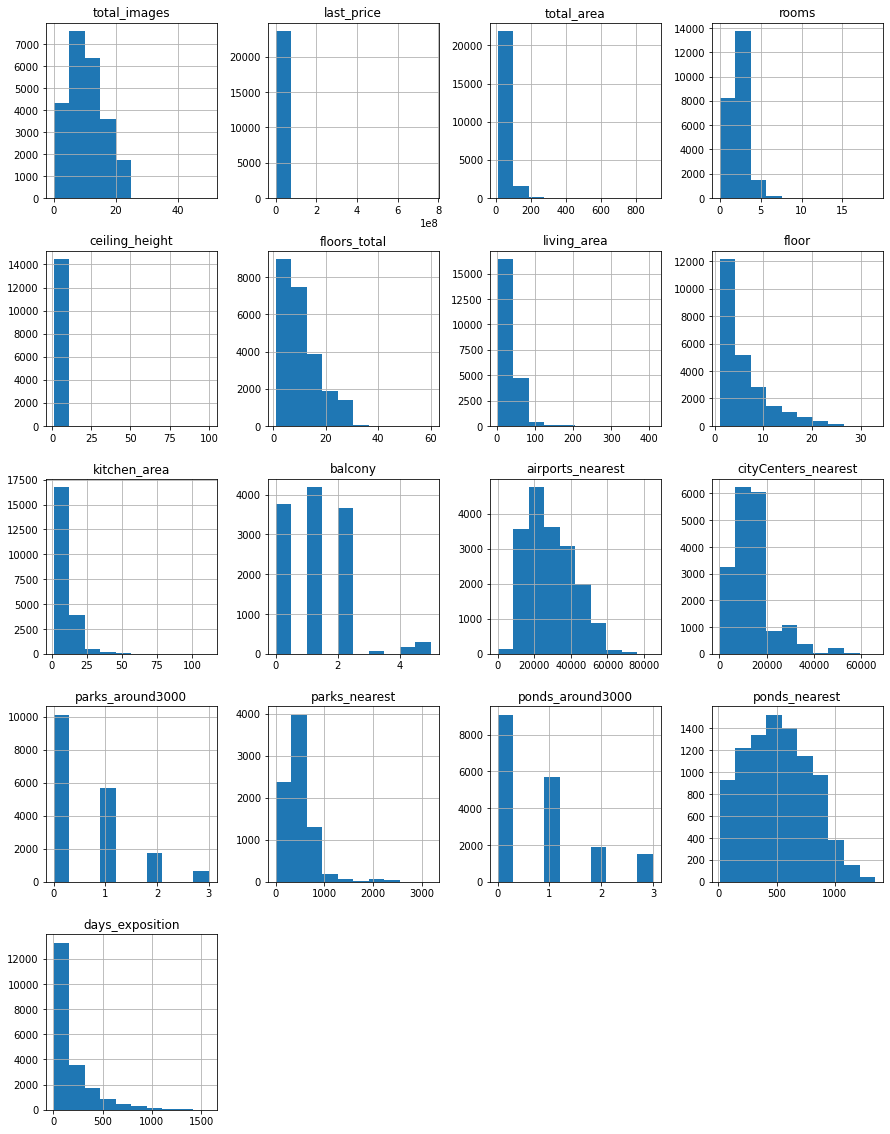

In [5]:
# Импорт библиотеки matplotlib для работы с графиками.
import matplotlib.pyplot as plt
# Построение гистограмм для всех числовых столбцов датафрейма.
data.hist(figsize=(15, 20))
plt.show()

In [6]:
# Приведение названия столбца к единому стилю.
data.rename(columns = {'cityCenters_nearest':'city_centers_nearest'}, inplace = True )

### Предобработка данных

#### Заполнение пропусков

**В столбцах "Высота потолков",  "Площадь кухни", "Жилая площадь"** данные заполняются вручную пользователем. Вероятней всего пропуски в данных столбцах образовались ввиду того, что пользователь по каким-то причинам не заполнил\пропустил данные поля при формировании объявления о продаже квартиры.

    
Заполним пропуски медианным значением.

In [7]:
# Заполнение пропущенных данных медианным значением в столбцах "Высота потолков", "Кол-во дней размещения объявления", "Площадь кухни", "Жилая площадь"
data[['ceiling_height','kitchen_area', 'living_area']] =\
data[['ceiling_height','kitchen_area', 'living_area']]\
.fillna(data[['ceiling_height','kitchen_area', 'living_area']].median())
# Вывод первых 10 строк для контроля заполнения пропущеных данных
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,2.65,11.0,18.60,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,2.65,5.0,34.30,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,2.65,14.0,30.00,9,NaN,...,9.10,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,2.65,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,2.65,26.0,10.60,6,NaN,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,2.65,24.0,30.00,22,NaN,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,2.65,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


**Колонка "Количество дней размещения объявления"** скорее всего считает кол-во дней автоматически после снятия объявления пользователем.
Причин пустых значений может быть несколько:
- сбой системы, не сработал счетчик
- пользователь забыл убрать объявление с размещения и возможно есть какой-то лимит после которого счетчик не считает
- или объявление разместили и сразу сняли
- возможно объявление не прошло модерацию

Для того, чтобы точно определить причины пустых значений необходима консультация эксперта, который объяснит алгоритм работы счетчика.**
Причинами пропусков по имеющимся данным можно назвать как микс технического сбоя и человеческого фактора.

Рассмотрим, как объявления распределяются по годам.


In [8]:
# Приведение к корректому типу данных столбец "Дата размещения объявления"
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%d')
data['year_exposition'] = pd.DatetimeIndex(data['first_day_exposition']).year
data_year_exposition = data.pivot_table(index='year_exposition', values = ['days_exposition', 'last_price'], aggfunc = 'count')
data_year_exposition.columns = ['exposition_count', 'advertising_total']
data_year_exposition

,exposition_count,advertising_total
year_exposition,,
2014,119,137
2015,1121,1191
2016,2716,2783
2017,7919,8190
2018,7560,8519
2019,1083,2879


В каждом году есть объявления , где не указано количество дней размещения объявления. Больше похоже на какую-то закономерность, скорее всего объявления по каким-то причинам были сняты, не выпущены к просмотру для потенциальных покупателей.

In [9]:
# Вывод уникальных значений и их кол-ва в столбце "Квартира".
data['is_apartment'].value_counts()

False    2725
True       50
Name: is_apartment, dtype: int64

**Столбец "Квартира"** определяет является ли недвижимость квартирой или нежилым помещением и заполняется пользователем. Возможно данное поле не является обязательным к заполнению или пользователи не воспринимают как обязательным к заполнению , так как есть много других параметров определяющих принадлежность к жилому помещению. Будем считать, что пропущенные данные являются определяющими по умолчанию принадлежность к жилому помещению.
    
Пропуски заполним единицей для дальнейшего корректого изменения типа данных на булев тип.

In [10]:
data['is_apartment'] = data['is_apartment'].fillna(False)

In [11]:
# Преобразование в тип данных "булев тип"
data['is_apartment'] = data['is_apartment'].astype('bool')

In [12]:
#Повторная проверка уникальных значений и их кол-ва, после изменения типа данных.
data['is_apartment'].value_counts()

False    23649
True        50
Name: is_apartment, dtype: int64

**Данные в столбцах "Количество прудов и парков в радиусе 3 км" и "Расстояние до ближайшего парка и пруда"** подтягиваются автоматически из геосервисов. Пропущеные данные свидетельсвуют об отсутсвии парков и прудов в радиусе 3 км.

Также пропущеные данные могли возникнуть из-за технического сбоя, например, в радиусе 3 км может быть пруд или парк , но может быть не указано расстояние. Проверим гипотезу технического сбоя.

In [13]:
# Проверка пересечений, есть ли данные по расстоянию до ближайшего парка, но с пропущенным кол-вом парков.
data.query('parks_around3000.isna() and parks_nearest > 0')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,year_exposition


In [14]:
# Проверка пересечений, есть ли парки в радиусе 3 км, но с пропущенным расстоянием до ближайшего парка.
data.query('parks_around3000 > 0 and parks_nearest.isna()')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,year_exposition


In [15]:
# Проверка пересечений, есть ли данные по расстоянию до ближайшего пруда, но с пропущенным кол-вом прудов.
data.query('ponds_around3000.isna() and ponds_nearest > 0')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,year_exposition


In [16]:
# Проверка пересечений, есть ли пруды в радиусе 3 км, но с пропущенным расстоянием до ближайшего пруда.
data.query('ponds_around3000 > 0 and ponds_nearest.isna()')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,year_exposition


Гипотеза технического сбоя в работе геосервисов оказалась ошибочной, значит, пропущенные данные скорее всего свидетельствут об отсутсвии парков и прудов в радиусе 3 км.
    
Все картографические данные оставим без изменений, чтобы не исказить данные.

**Столбец "Кол-во балконов"** заполняется вручную пользователем, логично предположить, что пропущенные данные свидетельсвуют об отсутвии балкона в квартире.
    
Заполним также пропуски нулями в данном столбце.

In [17]:
# Заполнение пропусков нулями.
data['balcony'] = data['balcony'].fillna(0)

**Данные в столбце " Общее количество этажей"** заполняет пользователь, соответсвенно причиной пропущенных данных является человеческий фактор, ошибка при ручном заполнении.

Также есть гипотеза, что данные пропущены в объявлениях по продаже частных домов или квартир в таунхаусах, то есть одноэтажных объектах. Проверим данную гипотезу, соответсвтенно, в колонке этаж размещения недвижимости должна быть указана "1".

In [18]:
# Вывод строк с пропущенными данными в колонке "количество этажей"
data[data['floors_total'].isna()]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,year_exposition
186,12,11640000.0,65.2,2018-10-02,2,2.65,NaN,30.80,4,False,...,0.0,Санкт-Петербург,39197.0,12373.0,1.0,123.0,0.0,NaN,49.0,2018
237,4,2438033.0,28.1,2016-11-23,1,2.65,NaN,20.75,1,False,...,0.0,Санкт-Петербург,22041.0,17369.0,0.0,NaN,1.0,374.0,251.0,2016
457,4,9788348.0,70.8,2015-08-01,2,2.65,NaN,38.40,12,False,...,0.0,Санкт-Петербург,37364.0,8322.0,2.0,309.0,2.0,706.0,727.0,2015
671,4,6051191.0,93.6,2017-04-06,3,2.65,NaN,47.10,8,False,...,0.0,Санкт-Петербург,22041.0,17369.0,0.0,NaN,1.0,374.0,123.0,2017
1757,5,3600000.0,39.0,2017-04-22,1,2.65,NaN,30.00,9,False,...,0.0,Санкт-Петербург,22735.0,11618.0,1.0,835.0,1.0,652.0,77.0,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22542,5,8500000.0,63.5,2017-05-24,2,2.80,NaN,30.00,3,False,...,0.0,Санкт-Петербург,51340.0,15363.0,0.0,NaN,1.0,853.0,512.0,2017
22656,4,4574160.0,64.5,2017-04-02,2,2.65,NaN,31.70,20,False,...,0.0,Санкт-Петербург,22041.0,17369.0,0.0,NaN,1.0,374.0,127.0,2017
22808,0,14569263.0,110.4,2016-11-20,3,2.65,NaN,45.38,6,False,...,0.0,Санкт-Петербург,19095.0,4529.0,0.0,NaN,0.0,NaN,260.0,2016
23590,0,21187872.0,123.3,2017-04-25,3,2.65,NaN,50.40,18,False,...,0.0,Санкт-Петербург,19095.0,4529.0,0.0,NaN,0.0,NaN,104.0,2017


Гипотеза одноэтажных домов не подтвердилась.
Заполним пропуски данными из колонки "этаж размещения квартиры", это будет более приближенно к реальности нежели заполнять медианным значением, так как есть квартиры на высоких этажах, например, 18 или 20 этаж, и медианное значение окажется меньше фактического расположения квартиры.

In [19]:
# Заполнение пропусков данными из соседней колонки.
data['floors_total'] = data['floors_total'].fillna(data['floor'])

**Название населенного пункта** заполняет пользователь, соответсвенно причиной пропущенных данных является человеческий фактор, ошибка при ручном заполнении.

В столбце мало пропусков - лучше сразу удалить их, чем заполнять значением, которое не является названием населенного пункта, чтобы не исказить дальнейший анализ.

In [20]:
data = data.dropna(subset=['locality_name'])

#### Обработка явных и неявных дубликатов

Для корректной работы с названиями населенных пунктов уберем неявные дубликаты в названиях и приведем названия к единому стилю.

In [21]:
# Формирование списка всех уникальных названий населенных пунктов.
data['locality_name'].unique().tolist()

['Санкт-Петербург',
 'посёлок Шушары',
 'городской посёлок Янино-1',
 'посёлок Парголово',
 'посёлок Мурино',
 'Ломоносов',
 'Сертолово',
 'Петергоф',
 'Пушкин',
 'деревня Кудрово',
 'Коммунар',
 'Колпино',
 'поселок городского типа Красный Бор',
 'Гатчина',
 'поселок Мурино',
 'деревня Фёдоровское',
 'Выборг',
 'Кронштадт',
 'Кировск',
 'деревня Новое Девяткино',
 'посёлок Металлострой',
 'посёлок городского типа Лебяжье',
 'посёлок городского типа Сиверский',
 'поселок Молодцово',
 'поселок городского типа Кузьмоловский',
 'садовое товарищество Новая Ропша',
 'Павловск',
 'деревня Пикколово',
 'Всеволожск',
 'Волхов',
 'Кингисепп',
 'Приозерск',
 'Сестрорецк',
 'деревня Куттузи',
 'посёлок Аннино',
 'поселок городского типа Ефимовский',
 'посёлок Плодовое',
 'деревня Заклинье',
 'поселок Торковичи',
 'поселок Первомайское',
 'Красное Село',
 'посёлок Понтонный',
 'Сясьстрой',
 'деревня Старая',
 'деревня Лесколово',
 'посёлок Новый Свет',
 'Сланцы',
 'село Путилово',
 'Ивангород',
 '

In [22]:
# Создание функции для определения вида населенного пункта.
def categorize_locality(row):
    try:
        if 'поселок ' in row or 'посёлок ' in row or 'товарищество' in row:
            return 'поселок'
        elif 'деревня ' in row:
            return 'деревня'
        elif 'село ' in row:
            return 'село'
        else:
            return 'город'
    except:
        return 'ошибка'

In [23]:
# Создание новой колонки с видом населенного пункта
data['locality_category'] = data['locality_name'].apply(categorize_locality)

In [24]:
# Приведение неявных дубликатов в слове "поселок" к универсальному написанию.
# Создание новой колонки с коротким названием населенного пункта.
data['locality_name_short'] = (
    data['locality_name']
    .str.replace('ё', 'е')
    .replace(['поселок ', 'деревня ', 'городского типа ', 'садовое товарищество ', 'садоводческое некоммерческое товарищество ', 'село ', 'городской ', 'станции ', 'при железнодорожной ','коттеджный '], '', regex=True)
) 
# Вывод нового списка с уникальными названиями населенных пунктов без дубликатов. 
data['locality_name_short'].unique().tolist()

['Санкт-Петербург',
 'Шушары',
 'Янино-1',
 'Парголово',
 'Мурино',
 'Ломоносов',
 'Сертолово',
 'Петергоф',
 'Пушкин',
 'Кудрово',
 'Коммунар',
 'Колпино',
 'Красный Бор',
 'Гатчина',
 'Федоровское',
 'Выборг',
 'Кронштадт',
 'Кировск',
 'Новое Девяткино',
 'Металлострой',
 'Лебяжье',
 'Сиверский',
 'Молодцово',
 'Кузьмоловский',
 'Новая Ропша',
 'Павловск',
 'Пикколово',
 'Всеволожск',
 'Волхов',
 'Кингисепп',
 'Приозерск',
 'Сестрорецк',
 'Куттузи',
 'Аннино',
 'Ефимовский',
 'Плодовое',
 'Заклинье',
 'Торковичи',
 'Первомайское',
 'Красное Село',
 'Понтонный',
 'Сясьстрой',
 'Старая',
 'Лесколово',
 'Новый Свет',
 'Сланцы',
 'Путилово',
 'Ивангород',
 'Шлиссельбург',
 'Никольское',
 'Зеленогорск',
 'Сосновый Бор',
 'Оржицы',
 'Кальтино',
 'Романовка',
 'Бугры',
 'Рощино',
 'Кириши',
 'Луга',
 'Волосово',
 'Отрадное',
 'Павлово',
 'Оредеж',
 'Копорье',
 'Молодежное',
 'Тихвин',
 'Победа',
 'Нурма',
 'Синявино',
 'Тосно',
 'Стрельна',
 'Бокситогорск',
 'Александровская',
 'Лопухинка'

In [25]:
# Вывод первых 10 строк для сверки
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,year_exposition,locality_category,locality_name_short
0,20,13000000.0,108.00,2019-03-07,3,2.70,16.0,51.00,8,False,...,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,2019,город,Санкт-Петербург
1,7,3350000.0,40.40,2018-12-04,1,2.65,11.0,18.60,1,False,...,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0,2018,поселок,Шушары
2,10,5196000.0,56.00,2015-08-20,2,2.65,5.0,34.30,4,False,...,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,2015,город,Санкт-Петербург
3,0,64900000.0,159.00,2015-07-24,3,2.65,14.0,30.00,9,False,...,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0,2015,город,Санкт-Петербург
4,2,10000000.0,100.00,2018-06-19,2,3.03,14.0,32.00,13,False,...,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0,2018,город,Санкт-Петербург
5,10,2890000.0,30.40,2018-09-10,1,2.65,12.0,14.40,5,False,...,NaN,NaN,NaN,NaN,NaN,NaN,55.0,2018,поселок,Янино-1
6,6,3700000.0,37.30,2017-11-02,1,2.65,26.0,10.60,6,False,...,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0,2017,поселок,Парголово
7,5,7915000.0,71.60,2019-04-18,2,2.65,24.0,30.00,22,False,...,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN,2019,город,Санкт-Петербург
8,20,2900000.0,33.16,2018-05-23,1,2.65,27.0,15.43,26,False,...,NaN,NaN,NaN,NaN,NaN,NaN,189.0,2018,поселок,Мурино
9,18,5400000.0,61.00,2017-02-26,3,2.50,9.0,43.60,7,False,...,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0,2017,город,Санкт-Петербург


In [26]:
# Вывод явных дубликатов
data.duplicated().sum()

0

#### Приведение к корректному типу данных.

Колонку с датой необходимо привести к типу данных "дата", для дальнейшего вычисления параметров, связанных с датой, а именно определение года размещения, месяц и день недели размещения.

In [27]:
# Приведение к корректому типу данных столбец "Дата размещения объявления"
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%d')

В данных кол-во этажей в доме, кол-во балконов, количество парков, количество прудов, количество дней размеения объявления не может быть дробных значений, поэтому необходимо привести к типу данных с целыми значениями.
Стоимость квартиры также не может быть дробной, так как стоимость указана в рублях, не в тысячах и не в миллионах.

In [28]:
# Приведение к корректому типу данных столбцов  "Последняя цена", "Кол-во этажей в доме", "Кол-во балконов"
data[['last_price','floors_total','balcony']] =\
data[['last_price','floors_total','balcony']].astype('int')

**Финальный вывод общей информации после предобработки данных.**

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23650 entries, 0 to 23698
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23650 non-null  int64         
 1   last_price            23650 non-null  int64         
 2   total_area            23650 non-null  float64       
 3   first_day_exposition  23650 non-null  datetime64[ns]
 4   rooms                 23650 non-null  int64         
 5   ceiling_height        23650 non-null  float64       
 6   floors_total          23650 non-null  int64         
 7   living_area           23650 non-null  float64       
 8   floor                 23650 non-null  int64         
 9   is_apartment          23650 non-null  bool          
 10  studio                23650 non-null  bool          
 11  open_plan             23650 non-null  bool          
 12  kitchen_area          23650 non-null  float64       
 13  balcony         

### Создание новых столбцов

#### Стоимость квадратного метра

In [30]:
# Создание нового столбца со стоимостью одного квадратного метра
data['price_of_square_meter'] = round(data['last_price']/data['total_area'],2)

#### День недели размещения объявления

In [31]:
# Создание нового столбца, день недели размещения объявления
data['day_of_week'] = pd.DatetimeIndex(data['first_day_exposition']).weekday 

#### Месяц размещения объявления

In [32]:
# Создание нового столбца, месяц размещения объявления
data['month_exposition'] = pd.DatetimeIndex(data['first_day_exposition']).month 

#### Год размещения объявления

In [33]:
# Создание нового столбца, год размещения объявления
data['year_exposition'] = pd.DatetimeIndex(data['first_day_exposition']).year

#### Тип этажа квартиры

In [34]:
# Создание функции для определения типа этажа квартиры
def floor_category(row):
    try:
        if row['floor'] == 1:
            return 'первый'
        elif row['floor']==row['floors_total']:
            return 'последний'
        else:
            return 'другой'
    except:
        return 'ошибка'
        

In [35]:
# Создание нового столбца с типом этажа квартиры
data['category_floor'] = data.apply(floor_category, axis=1)

#### Расстояние до центра города в км

In [36]:
# Создание нового столбца расстояние до центра города в км
data['city_centers_nearest_km'] = round(data['city_centers_nearest']/1000,0)
# Вывод первых 5 строк для контроля корректности произведенных действий
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_nearest,days_exposition,year_exposition,locality_category,locality_name_short,price_of_square_meter,day_of_week,month_exposition,category_floor,city_centers_nearest_km
0,20,13000000,108.0,2019-03-07,3,2.70,16,51.0,8,False,...,755.0,NaN,2019,город,Санкт-Петербург,120370.37,3,3,другой,16.0
1,7,3350000,40.4,2018-12-04,1,2.65,11,18.6,1,False,...,NaN,81.0,2018,поселок,Шушары,82920.79,1,12,первый,19.0
2,10,5196000,56.0,2015-08-20,2,2.65,5,34.3,4,False,...,574.0,558.0,2015,город,Санкт-Петербург,92785.71,3,8,другой,14.0
3,0,64900000,159.0,2015-07-24,3,2.65,14,30.0,9,False,...,234.0,424.0,2015,город,Санкт-Петербург,408176.10,4,7,другой,7.0
4,2,10000000,100.0,2018-06-19,2,3.03,14,32.0,13,False,...,48.0,121.0,2018,город,Санкт-Петербург,100000.00,1,6,другой,8.0


### Исследовательский анализ данных

#### Исследование параметра "Общая площадь"

In [37]:
# Вывод сводной статистики по столбцу "Общая площадь"
data['total_area'].describe()

count    23650.000000
mean        60.329069
std         35.661808
min         12.000000
25%         40.000000
50%         52.000000
75%         69.700000
max        900.000000
Name: total_area, dtype: float64

Среднее значение выше медианного ,максимальное значение сильно выбивается, что свидетельсвует о наличии выбросов в данных, которые влияют на разницу между средним и медианным значениями.

Определим при помощи диаграммы размаха диапазон выбросов.

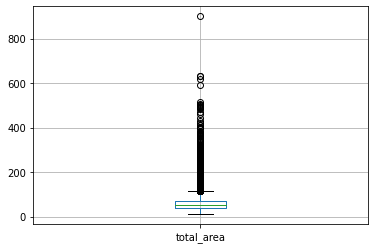

In [38]:
# Построение диаграммы размаха
import matplotlib.pyplot as plt
data.boxplot(column=['total_area'])
plt.show()

Согласно диаграмме размаха, общая площадь свыше 120 м2 попадает в зону выбросов. Скорее всего это элитная недвижимость.

Определим их кол-во, чтобы убедиться, что их можно исключить без потери большого кол-ва данных.

In [39]:
print('Количество квартир с большой площадью:', len(data.query('total_area > 120 ')))

Количество квартир с большой площадью: 1059


In [40]:
print('Процент квартир с большой площадью:', round(len(data.query('total_area > 120'))/len(data)*100, 2))


Процент квартир с большой площадью: 4.48


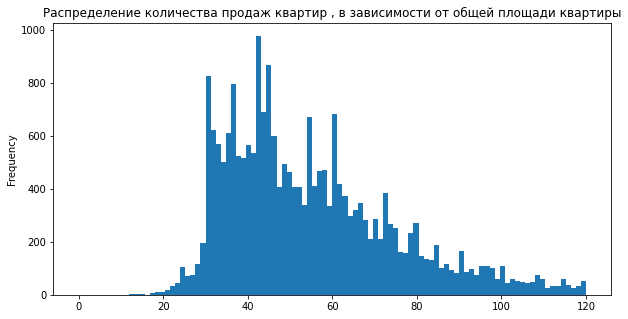

In [41]:
# Построение гистограммы с очищенными данными
data['total_area'].plot(
    kind ='hist',
    bins=100,
    range = (0, 120),
    figsize = (10,5),
    title = 'Распределение количества продаж квартир , в зависимости от общей площади квартиры'
)
plt.show()

Для построения финальной гистрограммы распределения кол-ва продаж квартир, в зависимости от общей площади квартиры отфильтровали выбросы : площадь свыше 120 м2, а также нежилые помещения.

Самое большое количество объявлений с общей площадью от 32 м2 до 62 м2.


#### Исследование параметра "Высота потолков"

In [42]:
# Вывод сводной статистики по столбцу "Высота потолков"
data['ceiling_height'].describe()

count    23650.000000
mean         2.724311
std          0.989255
min          1.000000
25%          2.600000
50%          2.650000
75%          2.700000
max        100.000000
Name: ceiling_height, dtype: float64

В данных явно присутсвуют аномалии, так как не существует высоты потолков 100 м.

Определим при помощи диаграммы размаха диапазон выбросов.

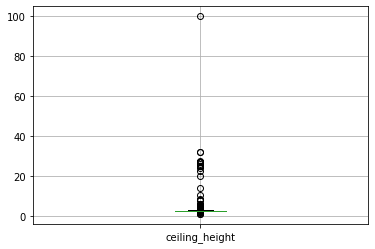

In [43]:
data.boxplot(column=['ceiling_height'])
plt.show()

Присутвуют данные с высотой потолков выше 20 м. Возможно при заполнении даных пользователь указал не метры , а сантиметры.

Пересчитаем такие данные в метры.

А также отфильтруем данные по высоте потолков , согласно стандартам жилых помещений высота потолков может быть от 2,4 м до 3 м.  И рассчитаем объем данных за рамками стандартов, чтобы убедиться, что их можно удалить без потери статистики.

In [44]:
data.loc[data['ceiling_height'] > 24, 'ceiling_height'] = data['ceiling_height']/10

In [45]:
print('Количество помещений с высотой потолков выше 3м:', len(data.query('ceiling_height > 3 ')))

Количество помещений с высотой потолков выше 3м: 1508


In [46]:
print('Процент помещений с высотой потолков выше 3м:', round(len(data.query('ceiling_height > 3'))/len(data)*100, 2))

Процент помещений с высотой потолков выше 3м: 6.38


In [47]:
print('Количество помещений с высотой потолков ниже 2.4 м:', len(data.query('ceiling_height < 2.4 ')))

Количество помещений с высотой потолков ниже 2.4 м: 21


In [48]:
print('Процент помещений с высотой потолков ниже 2.4 м:', round(len(data.query('ceiling_height < 2.4'))/len(data)*100, 2))

Процент помещений с высотой потолков ниже 2.4 м: 0.09


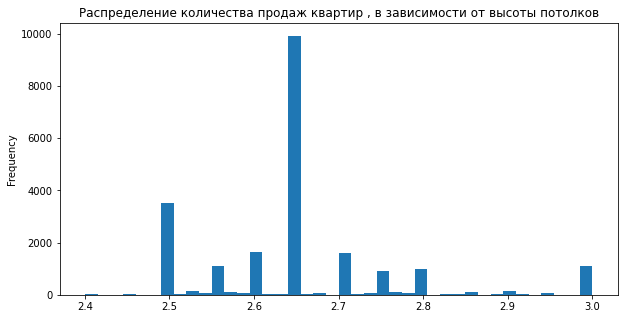

In [49]:
# Построение гистограммы с очищенными данными
data['ceiling_height'].plot(
    kind ='hist',
    bins=40,
    range = (2.4, 3.0),
    figsize = (10,5),
    title = 'Распределение количества продаж квартир , в зависимости от высоты потолков'
)
plt.show()

Для построения финальной гистрограммы распределения кол-ва продаж квартир, в зависимости от высоты потолков отфильтровали выбросы : потолки ниже 2,4 м и выше 3 м.

Самое большое количество объявлений с высотой потолков 2,65 м.

#### Исследование параметра "Жилая площадь"

In [50]:
# Вывод сводной статистики по столбцу
data['living_area'].describe()

count    23650.000000
mean        34.091359
std         21.169359
min          2.000000
25%         19.000000
50%         30.000000
75%         41.037500
max        409.700000
Name: living_area, dtype: float64

Среднее значение выше медианного ,максимальное значение сильно выбивается, что свидетельсвует о наличии выбросов в данных, которые влияют на разницу между средним и медианным значениями.

Определим при помощи диаграммы размаха диапазон выбросов.

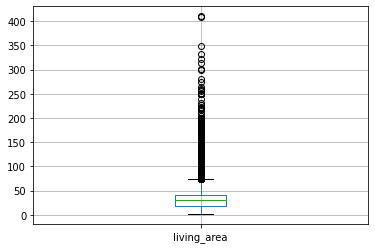

In [51]:
data.boxplot(column=['living_area'])
plt.show()

Согласно диаграмме размаха, жилая площадь свыше 80 м2 попадает в зону выбросов. Скорее всего это элитная недвижимость, по аналогии с параметром "Общая площадь".

Определим их кол-во, чтобы убедиться, что их можно исключить без потери большого кол-ва данных.

Жилая площадь 2 м2 можно было бы принять за аномалию, но учитывая, что существуют квартиры с общей площадью 12 м2, принимаем за норму.

In [52]:
print('Количество квартир с большой жилой площадью:', len(data.query('living_area > 80')))

Количество квартир с большой жилой площадью: 685


In [53]:
print('Процент квартир с большой жилой площадью:', round(len(data.query('living_area > 80'))/len(data)*100, 2))

Процент квартир с большой жилой площадью: 2.9


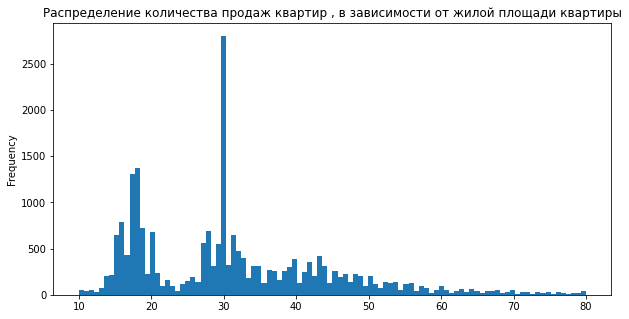

In [54]:
# Построение гистограммы с очищенными данными
data['living_area'].plot(
    kind ='hist',
    bins=100,
    range = (10, 80),
    figsize = (10,5),
    title = 'Распределение количества продаж квартир , в зависимости от жилой площади квартиры'
)
plt.show()

Для построения финальной гистрограммы распределения кол-ва продаж квартир, в зависимости от жилой площади квартиры отфильтровали выбросы : площадь свыше 80 м2, а также в соответствии со стандартами минимальной жилой площади взяли за минимум 10 м2.**

Значительно выделяется количество объявлений с жилой площадью 30 м2, их самое большое кол-во.

#### Исследование параметра "Площадь кухни".

In [55]:
# Вывод сводной статистики по столбцу
data['kitchen_area'].describe()

count    23650.000000
mean        10.425715
std          5.628088
min          1.300000
25%          7.300000
50%          9.100000
75%         11.427500
max        112.000000
Name: kitchen_area, dtype: float64

Среднее и медианное значение практически равны, значит, выбросов не так много, влияющих на статистику.

Определим при помощи диаграммы размаха диапазон выбросов.

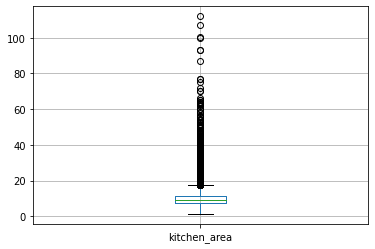

In [56]:
data.boxplot(column=['kitchen_area'])
plt.show()

Согласно диаграмме размаха, площадь кухни свыше 30 м2 попадает в зону выбросов.

Определим их кол-во, чтобы убедиться, что их можно исключить без потери большого кол-ва данных.

In [57]:
print('Количество квартир с большой кухней:', len(data.query('kitchen_area > 30')))

Количество квартир с большой кухней: 322


In [58]:
print('Процент квартир с большой кухней:', round(len(data.query('kitchen_area > 30'))/len(data)*100, 2))

Процент квартир с большой кухней: 1.36


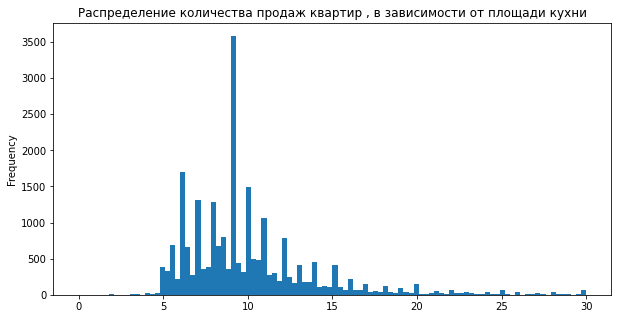

In [59]:
# Построение гистограммы с очищенными данными
data['kitchen_area'].plot(
    kind ='hist',
    bins=100,
    range = (0, 30),
    figsize = (10,5),
    title = 'Распределение количества продаж квартир , в зависимости от площади кухни'
)
plt.show()

Для построения финальной гистрограммы распределения кол-ва продаж квартир, в зависимости от площади кухни отфильтровали выбросы : площадь свыше 30 м2.

Значительно выделяется количество объявлений с площадью кухни 9 м2, их самое большое кол-во. Прослеживается влияние типовых застроек.

#### Исследование параметра "Кол-во комнат".

In [60]:
# Вывод сводной статистики по столбцу
data['rooms'].describe()

count    23650.000000
mean         2.070106
std          1.078620
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: rooms, dtype: float64

Среднее и медианное значение равны, но максимальное значение сзначительно отличается от 3 квартиля, значит, выбросы есть, но их не много, влияющих на статистику.

Определим при помощи диаграммы размаха диапазон выбросов.

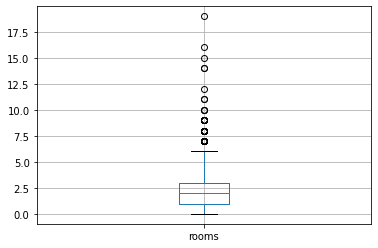

In [61]:
data.boxplot(column=['rooms'])
plt.show()

По диаграмме размаха видно, что количество комнат выше 7 являются выбросами, отнесем их также к элитной недвижимости.

Также посмотрим на данные , где количество комнат равно нулю.

In [62]:
# Срез данных по кол-ву комнат равных нулю.
data.query('rooms == 0')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_nearest,days_exposition,year_exposition,locality_category,locality_name_short,price_of_square_meter,day_of_week,month_exposition,category_floor,city_centers_nearest_km
144,1,2450000,27.00,2017-03-30,0,2.65,24,15.50,2,False,...,NaN,181.0,2017,поселок,Мурино,90740.74,3,3,другой,NaN
349,4,2320000,25.00,2017-09-27,0,2.65,14,17.00,1,False,...,NaN,45.0,2017,деревня,Кудрово,92800.00,2,9,первый,NaN
440,8,2480000,27.11,2018-03-12,0,2.65,17,24.75,4,False,...,982.0,64.0,2018,город,Санкт-Петербург,91479.16,0,3,другой,15.0
508,0,3375000,34.40,2017-03-28,0,2.65,26,24.30,19,False,...,593.0,430.0,2017,поселок,Парголово,98110.47,1,3,другой,19.0
608,2,1850000,25.00,2019-02-20,0,2.65,10,30.00,7,False,...,NaN,29.0,2019,поселок,Шушары,74000.00,2,2,другой,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23210,7,3200000,26.00,2017-09-01,0,2.65,25,18.00,16,False,...,623.0,14.0,2017,город,Санкт-Петербург,123076.92,4,9,другой,13.0
23442,0,2500000,27.70,2017-09-28,0,2.65,24,18.00,4,False,...,NaN,4.0,2017,поселок,Мурино,90252.71,3,9,другой,NaN
23554,15,3350000,26.00,2018-09-07,0,2.65,19,30.00,8,False,...,112.0,31.0,2018,город,Санкт-Петербург,128846.15,4,9,другой,17.0
23592,10,1450000,29.00,2017-11-11,0,2.65,9,18.00,8,False,...,NaN,82.0,2017,город,Никольское,50000.00,5,11,другой,NaN


Общая площадь такой недвижимости не выше 30 м2, что является характерным для квартир - студий. Принимаем такие данные за норму.

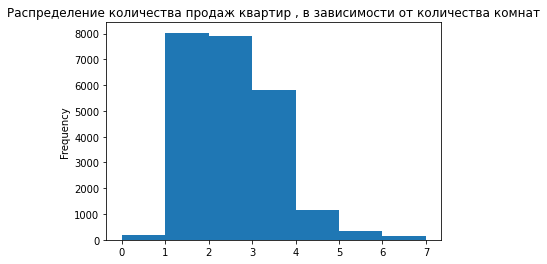

In [63]:
# Построение гистограммы с очищенными данными
data['rooms'].plot(
    kind ='hist',
    bins=7,
    range = (0, 7),
    title = 'Распределение количества продаж квартир , в зависимости от количества комнат'
)
plt.show()

Для построения финальной гистрограммы распределения кол-ва продаж квартир, в зависимости от количества комнат отфильтровали выбросы : количество комнат свыше 7.

Основная масса предложений по продаже недвижимости - это квартиры с 1,2 и 3-мя комнатами, больше всего однокомнатных квартир.

#### Исследование параметра "Этаж расположения квартиры".

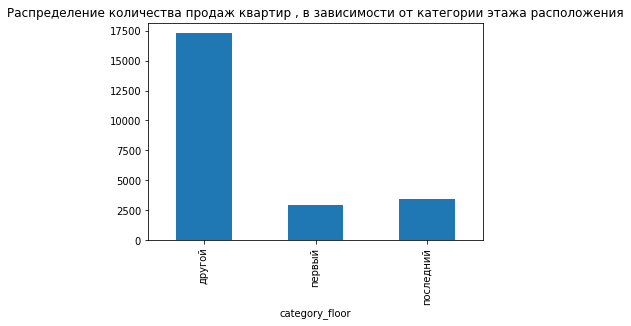

In [64]:
# Формирование сводной таблицы по категориям этажей для построения графика
# Построение графика 
(
    data
    .groupby(by='category_floor')['category_floor']
    .count()
    .plot(kind='bar', title = 'Распределение количества продаж квартир , в зависимости от категории этажа расположения')
)
plt.show()

In [65]:
# Расчет кол-ва квартир в зависимости от типа этажа расположения
data['category_floor'].value_counts()

другой       17326
последний     3412
первый        2912
Name: category_floor, dtype: int64

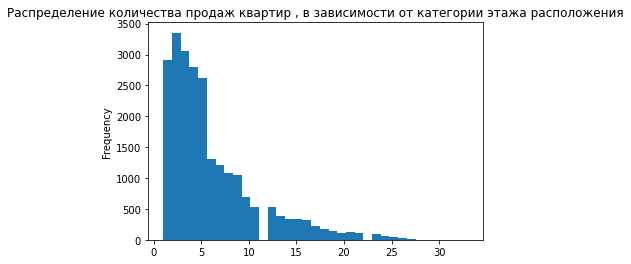

In [66]:
# Построение гистограммы  
data['floor'].plot(
    kind ='hist',
      bins=35,
    title = 'Распределение количества продаж квартир , в зависимости от категории этажа расположения'
)
plt.show()

Основная масса продаваемых квартир располагается на 1-5 этажах, при этом самое большое кол-во предложений  - это квартиры располагаемые на 2 этаже. А также  совокупность квартир на последнем и первом этажах составляет 25% об общей массы предложений. Можно предположить, что причиной такого большого кол-ва продаваемых квартир на первом и последнем этажах -  менее комфортное проживание в отношении других этажей.

#### Исследование параметра "Общее количество этажей в доме".

In [67]:
# Вывод сводной статистики по столбцу
data['floors_total'].describe()

count    23650.000000
mean        10.673784
std          6.593455
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

Среднее и медианное значения приближенны, однако опять наблюдается большой разрыв между 3 квартилем и максимальным значением, значит, выбросы есть.

Определим при помощи диаграммы размаха диапазон выбросов.

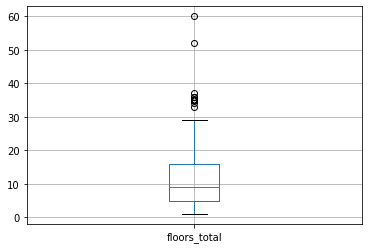

In [68]:
data.boxplot(column=['floors_total'])
plt.show()

Согласно диаграмме размаха, количество этажей свыше 30 уже редкость и попадает в зону выбросов.

По диаграмме размаха видно, что таких объявлений единиц, от них можно смело отказаться.

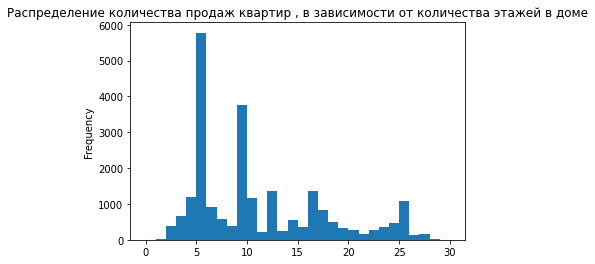

In [69]:
# Построение гистограммы с очищенными данными
data['floors_total'].plot(
    kind ='hist',
    bins=30,
    range = (0, 30),
    title = 'Распределение количества продаж квартир , в зависимости от количества этажей в доме'
)
plt.show()

Для построения финальной гистрограммы распределения кол-ва продаж квартир, в зависимости от количества этажей в доме отфильтровали выбросы : дома свыше 30 этажей.

Это даёт представление об инфраструктуре жилых домов в Ленинградской области: небоскребов практически нет, больше всего предложений в домах с 1-10 этажами, среди которых бОльшую массу занимают пятиэтажки.

#### Исследование  параметра "Расстояние от центра города".

In [70]:
# Вывод сводной статистики по столбцу
data['city_centers_nearest'].describe()

count    18139.000000
mean     14197.860742
std       8606.830295
min        181.000000
25%       9241.000000
50%      13105.000000
75%      16293.000000
max      65968.000000
Name: city_centers_nearest, dtype: float64

Среднее значение ниже медианного значения, значит, на статистику оказывают влияние данные, в которых нулевые расстояния до центра города. Исключим их из анализа.

Также рассмотрим диаграмму размаха для выявления выбросов.

In [71]:
# Создание новой переменной, в которй исключены объявления  с расстоянием о центра равным 0.
data_good_city_centers = data.query('city_centers_nearest > 0')

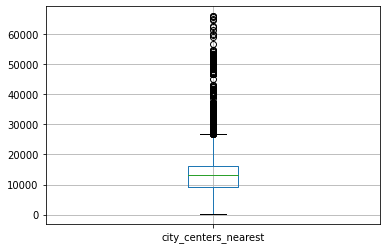

In [72]:
data_good_city_centers.boxplot(column=['city_centers_nearest'])
plt.show()

Согласно диаграмме размаха, расстояние до центра города свыше 3 км попадает в зону выбросов.

Определим их кол-во, чтобы убедиться, что их можно исключить без потери большого кол-ва данных.

In [73]:
print('Количество квартир, располагающихся далеко от центра:', len(data_good_city_centers.query('city_centers_nearest > 30000')))

Количество квартир, располагающихся далеко от центра: 1333


In [74]:
print('Процент квартир, располагающихся далеко от центра:', round(len(data.query('city_centers_nearest > 30000'))/len(data)*100, 2))

Процент квартир, располагающихся далеко от центра: 5.64


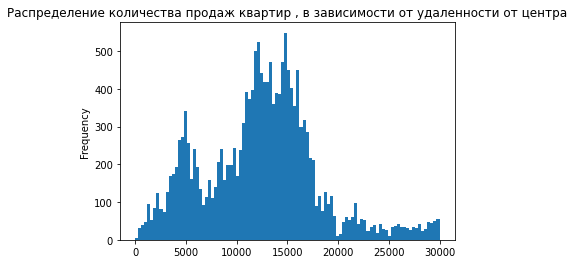

In [75]:
# Построение гистограммы с очищенными данными
data_good_city_centers['city_centers_nearest'].plot(
    kind ='hist',
    bins=100,
    range = (0, 30000),
    title = 'Распределение количества продаж квартир , в зависимости от удаленности от центра'
)
plt.show()

Для построения финальной гистрограммы распределения кол-ва продаж квартир, в зависимости от расстояния до центра города отфильтровали выбросы : расстояние свыше 3 км, а также убрали объявления с отутствующей информацией.

Типичное расположение от центра города находится в ддиапазоне от 1 км до 1 км 750 м. Больше всего предложений с удаленностью 1 км 250 м

#### Исследование параметра "Расстояние до ближайшего парка".

In [76]:
# Вывод сводной статистики по столбцу
data['parks_nearest'].describe()

count    8064.000000
mean      490.830729
std       342.554386
min         1.000000
25%       288.000000
50%       454.500000
75%       612.000000
max      3190.000000
Name: parks_nearest, dtype: float64

Медиана равна нулю, значит, превалируют объявления, в которых нет рядом парков. Очистим данные, чтобы убрать влияние на остальные данные.

Также рассмотрим диаграмму размаха для выявления выбросов.

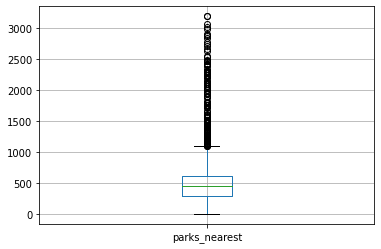

In [77]:
data.boxplot(column=['parks_nearest'])
plt.show()

Согласно диаграмме размаха, расстояние до ближайшего парка свыше 800 м попадает в зону выбросов.

Определим их кол-во, чтобы убедиться, что их можно исключить без потери большого кол-ва данных.

In [78]:
print('Количество квартир, располагающихся далеко от парка:', len(data.query('parks_nearest > 800')))

Количество квартир, располагающихся далеко от парка: 724


In [79]:
print('Процент квартир, располагающихся далеко от парка:', round(len(data.query('parks_nearest > 800'))/len(data)*100, 2))

Процент квартир, располагающихся далеко от парка: 3.06


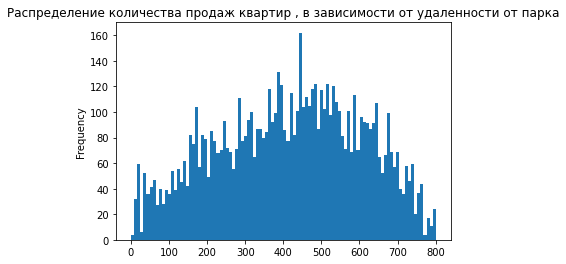

In [80]:
# Построение гистограммы с очищенными данными.
data['parks_nearest'].plot(
    kind ='hist',
    bins=100,
    range = (1, 800),
    title = 'Распределение количества продаж квартир , в зависимости от удаленности от парка'
)
plt.show()

In [81]:
# Определение кол-ва квартир , рядом с которыми нет парков
len(data[data['parks_nearest'] == 0])

0

Для построения финальной гистрограммы распределения кол-ва продаж квартир, в зависимости от расстояния до парка отфильтровали выбросы : расстояние свыше 800 м, а также убрали объявления, без парков.

Анализ показал, что рядом с 65% квартир отсутствуют парки, только 35% квартир располагаются с парками, из них самое большое кол-во квартир распологагается в 450 от ближайшего парка.

#### Исследование параметра "Стоимость квартиры".

In [82]:
# Вывод сводной статистики по столбцу
data['last_price'].describe()

count    2.365000e+04
mean     6.541127e+06
std      1.089640e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.650000e+06
75%      6.799000e+06
max      7.630000e+08
Name: last_price, dtype: float64

In [83]:
# устанавливаю настройку для приведения в нормальный числовой формат
pd.options.display.float_format = '{:.2f}'.format

In [84]:
# Вывод сводной статистики по столбцу
data['last_price'].describe()

count       23650.00
mean      6541126.90
std      10896399.18
min         12190.00
25%       3400000.00
50%       4650000.00
75%       6799000.00
max     763000000.00
Name: last_price, dtype: float64

Среднее значение значительно выше медианного, значит, а максимальное значение сильно отличается от 3 квартиля.**

Рассмотрим диаграмму размаха для выявления выбросов.

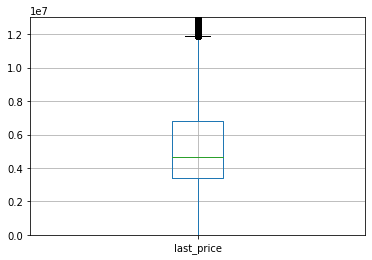

In [85]:
data.boxplot(column=['last_price'])
plt.ylim(0,13000000)
plt.show()

Согласно диаграмме размаха, стоимость квартиры свыше 12 млн. руб. попадает в зону выбросов.

Определим их кол-во, чтобы убедиться, что их можно исключить без потери большого кол-ва данных.

In [86]:
print('Количество квартир, c высокой ценой:', len(data.query('last_price > 12000000')))

Количество квартир, c высокой ценой: 1936


In [87]:
print('Процент квартир, c высокой ценой:', round(len(data.query('last_price > 12000000'))/len(data)*100, 2))

Процент квартир, c высокой ценой: 8.19


In [88]:
data_last_price_good = len(data.query('last_price < 12000000'))
data_last_price_good

21656

In [89]:
print('Процент потери данных:', round((data_total-data_last_price_good)/data_total, 2))

Процент потери данных: 0.09


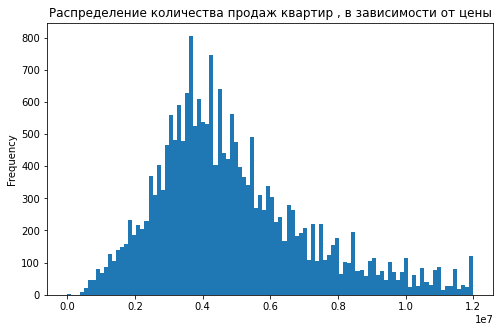

In [90]:
# Построение гистограммы с очищенными данными.
data['last_price'].plot(
    kind ='hist',
    bins=100,
    figsize = (8,5),
    range = (0, 12000000),
    title = 'Распределение количества продаж квартир , в зависимости от цены'
)
plt.show()

Для построения финальной гистрограммы распределения кол-ва продаж квартир, в зависимости от расстояния до стоимости, отфильтровали выбросы : цены свыше 12 млн руб.

Основная масса объявлений находится в диапазоне стоимости от 3 до 5,5 млн руб, среди которых превалируют объявления стоимостью около 3,9 млн. руб., вторая по значимости цена 4,2 млн. руб.

#### Исследование параметра "Количество дней размещения объявления о продаже".

In [91]:
# Вывод сводной статистики по столбцу
data['days_exposition'].describe()

count   20470.00
mean      180.75
std       219.78
min         1.00
25%        45.00
50%        95.00
75%       231.00
max      1580.00
Name: days_exposition, dtype: float64

Среднее значение практически в 2 раза больше медианного значения, значит, есть необычно долгие продажи квартир, которые влияют на статистику.

Рассмотрим диаграмму размаха для выявления выбросов.

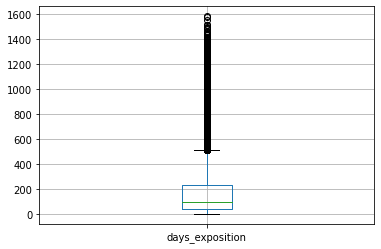

In [92]:
data.boxplot(column=['days_exposition'])
plt.show()

Продажи длительностью свыше 500 дней находятся в зоне выбросов.
Определим их кол-во.

In [93]:
print('Количество квартир, c долгой продажей :', len(data.query('days_exposition > 500')))

Количество квартир, c долгой продажей : 1744


In [94]:
print('Процент квартир, c долгой продажей:', round(len(data.query('days_exposition > 500'))/len(data)*100, 2))

Процент квартир, c долгой продажей: 7.37


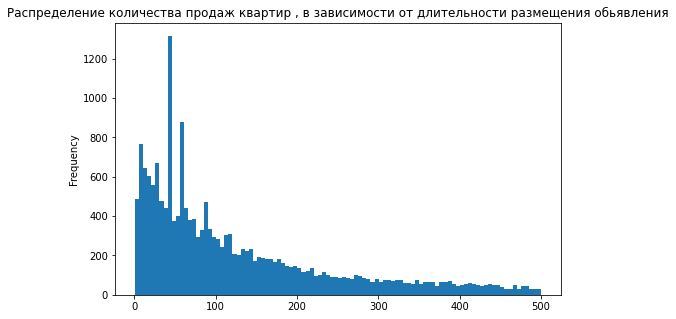

In [95]:
# Построение гистограммы с очищенными данными.
data['days_exposition'].plot(
    kind ='hist',
    bins=100,
    figsize = (8,5),
    range = (1,500),
    title = 'Распределение количества продаж квартир , в зависимости от длительности размещения обьявления'
)
plt.show()

Для построения финальной гистрограммы распределения кол-ва продаж квартир, в зависимости от длительности продажи, отфильтровали выбросы : длительность свыше 500 дней.

Необычно долгими продажами можно считать продажи свыше 3 квартиля , а именно больше 231 дней. Самая необычно долгая продажа состоялась только через 4 года после размещения объявления. также необычно быстрые продажи можно считать продажами до 1 квартиля, до 45 дней.

### Выявление факторов, влияющих на стоимость квартиры.

In [96]:
# Создание функции для номерной категоризации этажа расположения квартиры.
def floor(row):
    try:
        if row == 'первый':
            return '1'
        elif row =='другой':
            return '2'
        else:
            return '3'
    except:
        return 'ошибка'
data['category_floor_number'] =data['category_floor'].apply(floor).astype('int')

In [97]:
# Вычисление коэффициентов корреляции влияния на стоимость квартиры по факторам ниже:
print('Коэффициент корреляции стоимости квартиры и общей площади квартиры:', round(data['last_price'].corr(data['total_area']),2))
print('Коэффициент корреляции стоимости квартиры и жилой площади квартиры:', round(data['last_price'].corr(data['living_area']),2))
print('Коэффициент корреляции стоимости квартиры и площади кухни:', round(data['last_price'].corr(data['kitchen_area']),2))
print('Коэффициент корреляции стоимости квартиры и количества комнат:', round(data['last_price'].corr(data['rooms']),2))

Коэффициент корреляции стоимости квартиры и общей площади квартиры: 0.65
Коэффициент корреляции стоимости квартиры и жилой площади квартиры: 0.54
Коэффициент корреляции стоимости квартиры и площади кухни: 0.44
Коэффициент корреляции стоимости квартиры и количества комнат: 0.36


Прослеживается среднее влияние общей площади и жилой площади на стоимость цены, больше всего влияния оказывает общая площадь квартиры.Слабое влияние оказывает площадь кухни и количество комнат.

Попробуем очистить выбросы в стоимости квартиры и рассмотрим ещё раз коэффициент корреляции по данным параметрам.

In [98]:
# Фильтрация стоимости, с учетом межквартильного размаха
q1 = data['last_price'].quantile(0.25)
q3 = data['last_price'].quantile(0.75)
iqr = q3 - q1
data_price_good = data.query('last_price < (@q3 + 1.5*@iqr) and  last_price > (@q1 - 1.5*@iqr)  ')
len(data_price_good)

21595

In [99]:
print('Процент потери данных:', round((data_total-len(data_price_good))/data_total, 2))

Процент потери данных: 0.09


In [100]:
# Вычисление коэффициентов корреляции влияния на стоимость квартиры, с очищенными данными:
print('Коэффициент корреляции стоимости квартиры и общей площади квартиры:', round(data_price_good['last_price'].corr(data_price_good['total_area']),2))
print('Коэффициент корреляции стоимости квартиры и жилой площади квартиры:', round(data_price_good['last_price'].corr(data_price_good['living_area']),2))
print('Коэффициент корреляции стоимости квартиры и площади кухни:', round(data_price_good['last_price'].corr(data_price_good['kitchen_area']),2))
print('Коэффициент корреляции стоимости квартиры и количества комнат:', round(data_price_good['last_price'].corr(data_price_good['rooms']),2))

Коэффициент корреляции стоимости квартиры и общей площади квартиры: 0.7
Коэффициент корреляции стоимости квартиры и жилой площади квартиры: 0.55
Коэффициент корреляции стоимости квартиры и площади кухни: 0.46
Коэффициент корреляции стоимости квартиры и количества комнат: 0.45


Показатели улучшились: самое высокое влияние на стоимость квартиры оказывает обая площадь квартиры, но тем не менее влияние не прямое, среднее влияние оказывает жилая площадь, площадь кухки и кодичество комнат также осталось слабым влиянием.
От этажа расположения и даты размещения по-прежнему не зависит цена.

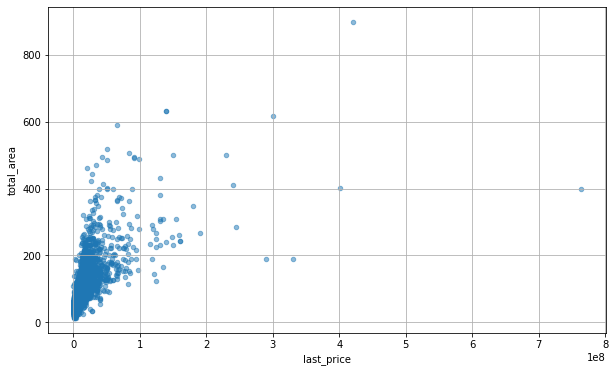

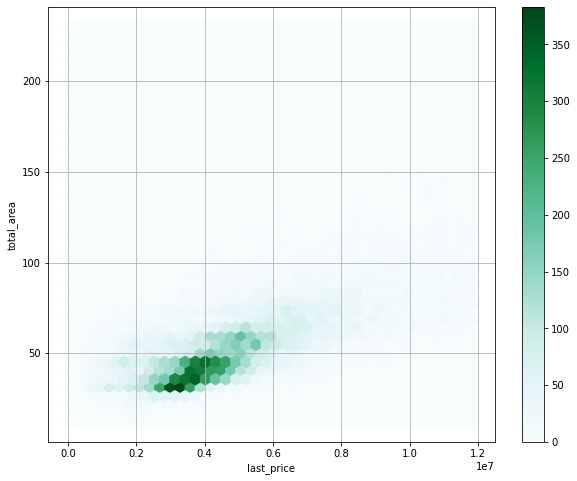

In [101]:
# Построение диаграмм рассеяния влияния общей площади квартиры на стоимость 
data.plot(x='last_price', y='total_area', kind='scatter' , alpha=0.5, grid=True, figsize=(10, 6))
data_price_good.plot(x='last_price', y='total_area', kind='hexbin', gridsize=40, figsize=(10, 8), sharex=False, grid=True)
plt.show()

Самая большая зависимость влияния общей  площади на стоимость квартиры в диапазоне от 30 до 50 м2, цена колеблется в диапазоне от 3 до 4,5 млн руб.

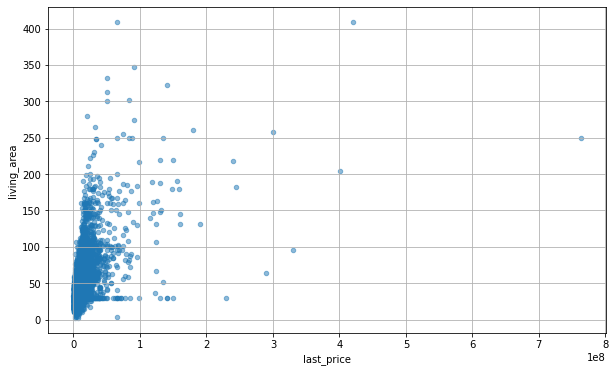

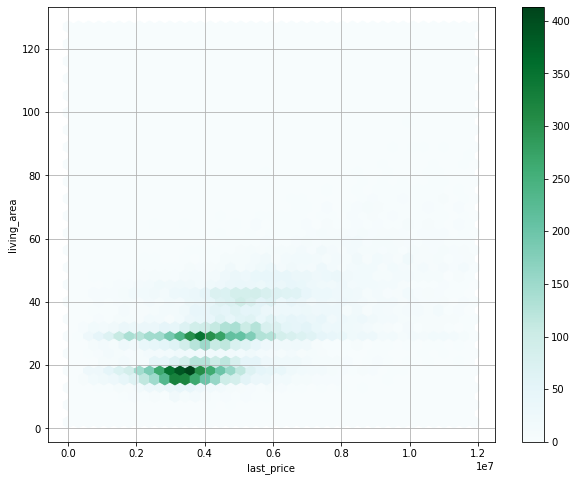

In [102]:
# Построение диаграмм рассеяния влияния жилой площади квартиры на стоимость 
data.plot(x='last_price', y='living_area', kind='scatter' , alpha=0.5, grid=True, figsize=(10, 6))
data_price_good.plot(x='last_price', y='living_area', kind='hexbin', gridsize=40, figsize=(10, 8), sharex=False, grid=True)
plt.show()

По диаграмме проселживается зависимость стоимости квартир с жилой площадью от 15 до 19 м2 в диапазоне от от 3 до 4 млн. руб. А также видно, что квартиры с жилой площадью 35 м2 могут стоить от 2 млн. руб. до 6 млн. руб., чаще всего встречается стоимость  3,9 млн. руб. В остальном практически нет зависимости стоимости от жилой влощади.

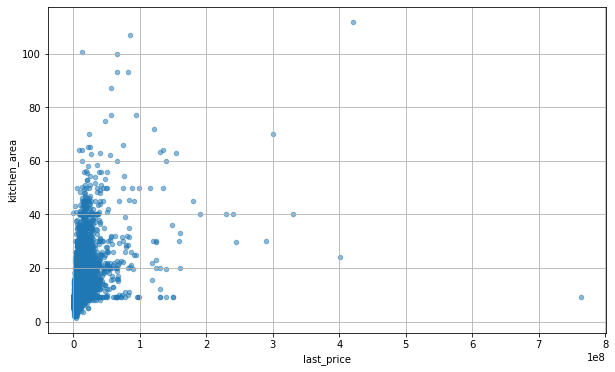

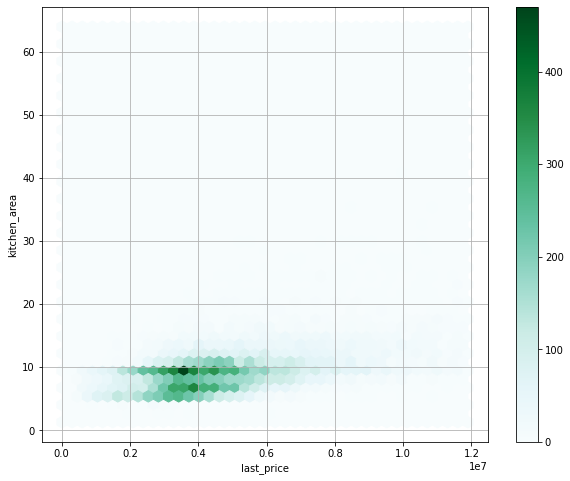

In [103]:
# Построение диаграмм рассеяния влияния площади кухни квартиры на стоимость 
data.plot(x='last_price', y='kitchen_area', kind='scatter' , alpha=0.5, grid=True, figsize=(10, 6))
data_price_good.plot(x='last_price', y='kitchen_area', kind='hexbin', gridsize=40, figsize=(10, 8), sharex=False, grid=True)
plt.show()

По диаграмме зависимости стоимости от площади кухни видно, что влияние слабое,  много объявлений с площадью 9 м2, но дипазон стоимости колеблется от 2 до 6 млн. руб., чаще всего стоимость такой квартиры 3,8 млн. руб. С другими площадями ещё меньшее влияние на цену.

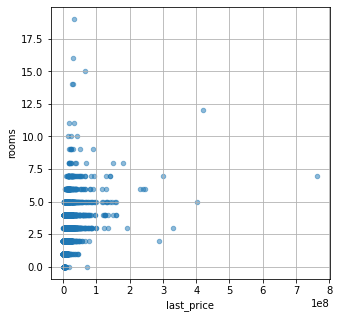

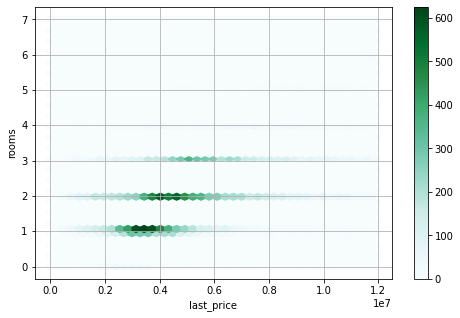

In [104]:
# Построение диаграмм рассеяния влияния кол-ва комнат в  квартире на стоимость 
data.plot(x='last_price', y='rooms', kind='scatter' , alpha=0.5, grid=True, figsize=(5, 5))
data_price_good.plot(x='last_price', y='rooms', kind='hexbin', gridsize=40, figsize=(8, 5), sharex=False, grid=True)
plt.show()

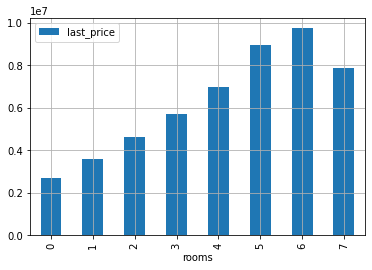

In [105]:
# Расчет самой популярной цены в зависимости от кол-ва комнат
data_price_good.pivot_table(index ='rooms', values ='last_price', aggfunc = 'median').reset_index().plot(x='rooms', y='last_price', kind='bar' , grid=True)
plt.show()

По диаграмме также наблюдается разброс цен на 1,2 и 3-ех комнатные квартиры, при этом цена может быть одинаковой на 1,2 и 3-ех комнатные квартры.

Однокомнатные чаще всего стоят от 3 до 4 млн. руб. Двухкомнатные квартиры чаще всего стоят от 3,9 до 4,3 млн. руб. В остальных случаях зависимость трудно определить.

Расчет средней цены показал, средняя цена растет в зависимости от кол-ва комнат в квартире, квартиры-студии самые дешевые, самые дорогие 6-и комнатные квартиры. Стоимость 7-ми комнатных квартир между стоимость 4 и 5 комнатными квартирами, видимо такие квартиры не практичны с точки зрения проживания.

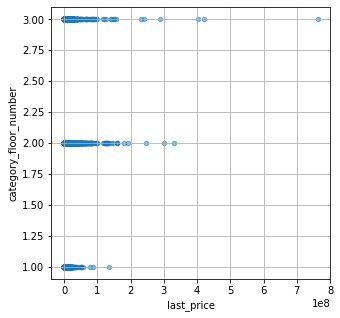

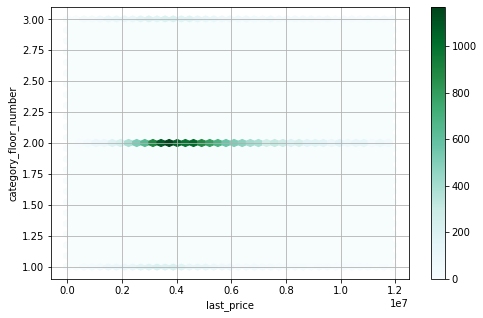

In [106]:
# Построение диаграмм рассеяния влияния категории этажа расположения квартиры на стоимость 
data.plot(x='last_price', y='category_floor_number', kind='scatter' , alpha=0.5, grid=True, figsize=(5, 5))
data_price_good.plot(x='last_price', y='category_floor_number', kind='hexbin', gridsize=40, figsize=(8, 5), sharex=False, grid=True)
plt.show()

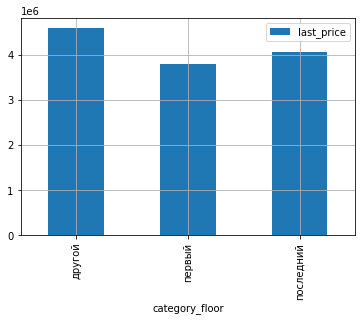

In [107]:
# Расчет самой популярной цены в зависимости от этажа расположения
data_price_good.pivot_table(index ='category_floor', values ='last_price', aggfunc = 'median').reset_index().plot(x='category_floor', y='last_price', kind='bar' , grid=True)
plt.show()

По диаграммам видно, что никакой зависимости стоимости от этажа расположения нет. Единственное, что можно сказать, что квартиры на первом этаже стоят дешевле, на втором месте квартиры на послденм этаже и самые дорогие квартиры на промежуточных этажах. Можно подтвердить гипотезу, что проживание на первом и послденем этажах менее комфортно, чем на промежуточных этажах и поэтому меньше ценятся.

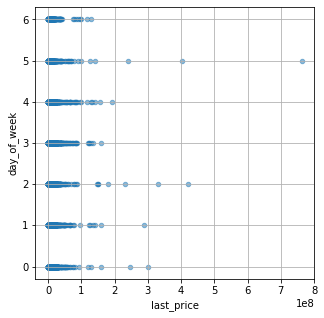

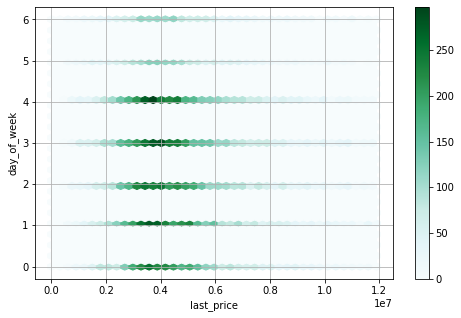

In [108]:
# Построение диаграмм рассеяния влияния дня недели размещения объявления на стоимость 
data.plot(x='last_price', y='day_of_week', kind='scatter' , alpha=0.5, grid=True, figsize=(5, 5))
data_price_good.plot(x='last_price', y='day_of_week', kind='hexbin', gridsize=40, figsize=(8, 5), sharex=False, grid=True)
plt.show()

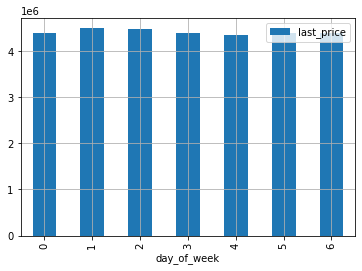

In [109]:
# Расчет самой популярной цены в  зависимости от дня недели размещения объявления
data_price_good.pivot_table(index ='day_of_week', values ='last_price', aggfunc = 'median').reset_index().plot(x='day_of_week', y='last_price', kind='bar' , grid=True)
plt.show()

Наблюдается полное отсутсвие зависимости стоимости квартир от дня недели размещения объявления

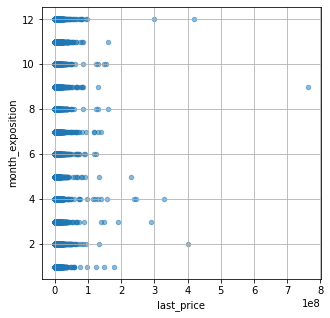

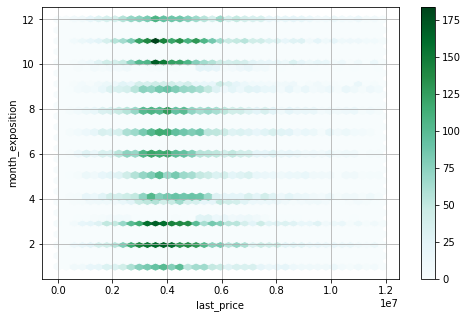

In [110]:
# Построение диаграмм рассеяния влияния месяца размещения объявления на стоимость 
data.plot(x='last_price', y='month_exposition', kind='scatter' , alpha=0.5, grid=True, figsize=(5, 5))
data_price_good.plot(x='last_price', y='month_exposition', kind='hexbin', gridsize=40, figsize=(8, 5), sharex=False, grid=True)
plt.show()

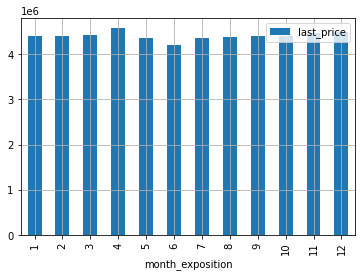

In [111]:
# Расчет самой популярной цены в  зависимости от месяца размещения объявления
data_price_good.pivot_table(index ='month_exposition', values ='last_price', aggfunc = 'median').reset_index().plot(x='month_exposition', y='last_price', kind='bar' , grid=True)
plt.show()

Наблюдается полное отсутсвие зависимости стоимости квартир от месяца размещения объявления

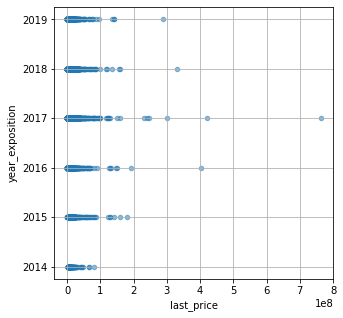

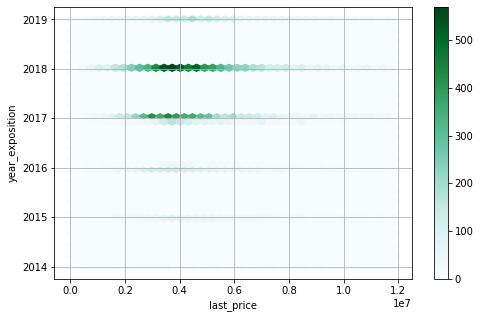

In [112]:
# Построение диаграмм рассеяния влияния года размещения объявления на стоимость 
data.plot(x='last_price', y='year_exposition', kind='scatter' , alpha=0.5, grid=True, figsize=(5, 5))
data_price_good.plot(x='last_price', y='year_exposition', kind='hexbin', gridsize=40, figsize=(8, 5), sharex=False, grid=True)
plt.show()

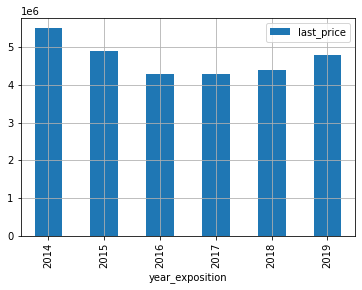

In [113]:
# Расчет самой популярной цены в  зависимости от года размещения объявления
(
    data_price_good.pivot_table(index ='year_exposition', values ='last_price', aggfunc = 'median')
    .reset_index()
    .plot(x='year_exposition', y='last_price', kind='bar' , grid=True)
)
plt.show()

С 2014 года по 2017 наблюдается снижение медианной стоимости квартир и далее повышение с в 2018 и 2019 году. Но по диаграмме размаха видно, что прямой закономерности влияния года от стоимости нет.

### Средняя стоимость квадратного метра в топ-10 населенных пунктах

In [114]:
# Расчет средней стоимости 1 м2
data['cost_square_meter'] = data['last_price']/data['total_area']

In [115]:
# Выделение топ-10 городов с самым большим кол-вом объявлений
# Расчет усредненной стоимости 1 м2 в каждом городе
top_10_locality = data.pivot_table(index = 'locality_name_short', values = 'cost_square_meter', aggfunc = ['count', 'mean'])
top_10_locality.columns = ['count_apartment', 'cost_square_meter']
top_10_locality = top_10_locality.sort_values(by = 'count_apartment',ascending = False).head(10)
top_10_locality

,count_apartment,cost_square_meter
locality_name_short,,
Санкт-Петербург,15721,114849.01
Мурино,590,86087.51
Кудрово,472,95324.93
Шушары,440,78677.36
Всеволожск,398,68654.47
Пушкин,369,103125.82
Колпино,338,75424.58
Парголово,327,90175.91
Гатчина,307,68746.15


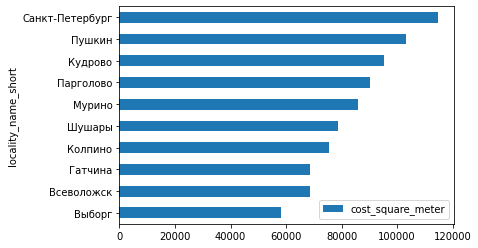

In [116]:
# Распределение средней цены 1 м2 в топ-10 населенных пунктах
top_10_locality.sort_values('cost_square_meter').plot(y ='cost_square_meter', kind='barh')
plt.show()

Самая дорогая стоимость одного м2 в Санкт-Петербурге, что логично по отношению в ближприлежащим населенным пунктам. На втором и третьем месте Пушкин и Кудрово. В Выборге самая дешевая стоимость одного м2, вероятно потому что этот населенный пункт располагается дальше остальных от Санкт-Петербурга из списка топ-10.

### Стоимость объектов в зависимости от расстояния до центра города.

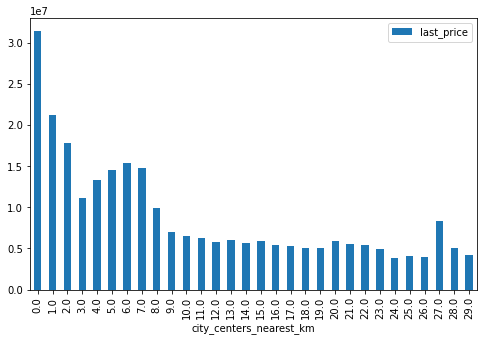

In [117]:
# Расчет средней стоимости удаленности от центра города с шагом в 1 км.
(
    data[data['locality_name']=='Санкт-Петербург']
    .pivot_table(index='city_centers_nearest_km',values='last_price',aggfunc='mean')
    .plot(kind='bar', figsize = (8,5))
)
plt.show()

Согласно графику средняя стоимость квартиры снижается по мере удаленности от центра города. Наблюдается повышение средней стоимости на 5 и 6 км и на 27 км от центра города, возможно это особенные районы, более элитные или исторически значимые.


### Общий вывод

**Для проведения анализа были выполнены следующие шаги:**

**1. Заполнены пропущенные значения в столбцах:**

- ceiling_height
- floors_total
- living_area
- is_apartment
- kitchen_area
- balcony
- locality_name
- airports_nearest
- cityCenters_nearest
- parks_around3000
- parks_nearest
- ponds_around3000
- ponds_nearest
- days_exposition

Основная масса пропусков объясняется человеческим фактором - это параметры, которые должен заполнить пользователь.
Пропуски в данном случае делятся на 2 вида:
1. Пропущенные данные, которые обязательно должны быть, такие как указание площадей недвижимости
2. Пропущенные данные, в виду того, что они отсутсвуют у объекта недвижимости, например, отсутвие балкона.
К ошибкам человеческого фактора также относятся аномалии в данных, а именно некорректно заполненные поля, например, указана высота потолков не в метрах , а сантиметрах.

**Рекомендации:**

Для снижения потери данных можно порекомендовать расширить список полей обязательными для заполнения, например, в случае отсутвия балконов обязательно поставить 0.
Для некоторых полей можно установить всплывающие списки вместо ручного ввода, например, для высоты потолков.

В пропущенных данных также встречаются эпизоды технического сбоя в геосервисах, например, для одного и тоже населенного пунка присутсвуют и отсутствуют данные по удаленности от центра города и аэропорта.

В случае с пропусками в количестве дней размещения объявлений  скорее всего причиной является микс технического сбоя и человеческого фактора. Но для точного определения необходима дополнительная информация по алгоритму работы счетчика.

**2. Проведена проверка на предмет явных дубликатов, дубликаты отсутствуют.**

**3. Названия населенных пунктов были приведены к универсальным названиям, устранены неявные дубликаты в названиях.**

**4. Колонки с некорректными типами данных приведены в соответсвие:**
- last_price
- floors_total
- balcony
- parks_around3000
- ponds_around3000
- days_exposition
- first_day_exposition
- is_apartment

**5. Добавлены новые столбцы:**

- цена одного квадратного метра с округлением  до двух знаков после запятой
- день недели публикации объявления (0 — понедельник, 1 — вторник и так далее)
- месяц публикации объявления (1 - январь, 2 - февраль и так далее)
- год публикации объявления
- тип этажа квартиры (значения — «первый», «последний», «другой»)
- расстояние до центра города в километрах, округленное до целых значений

**6. Проведен исследовательский анализ и выявлено несколько типичных признаков для недвижимости Санкт-Петербурга и области, а также влияние факторов на стоимость недвижимости:**

Это квартира общей площадью 42 м2 с высотой потолков 2,65 м, жилой площадью 30 м2, площадью кухни 9 м2, одна или двух комнатная, располагающаяся в пятиэтажном доме на 2,3 или 4 этаже.  Располагается в 1 км 250 м от центра города, рядом парков нет. Стоимость такой квартиры от 3 до 5,5 млн. руб.
Такую квартиру можно продать за 95 дней.

В основном квартиры продаются с общей площадью от 32 м2 до 62 м2, с 1,2 и 3-мя комнатами. 
Самое большое влияние на цену квартиры оказывает общая площадь недвижимости.
Самая большая зависимость прослеживается в диапазоне от 30 до 50 м2, цена колеблется в диапазоне от 3 до 4,5 млн руб.
На втором месте по значимости на стоимость оказывает влияние размер жилой площади, но влияние уже более слабое. Квартиры с жилой площадью от 15 до 19 м2 в диапазоне от от 3 до 4 млн. руб. Однако квартиры с жилой площадью 35 м2 могут стоить от 2 млн. руб. до 6 млн. руб. Разрыв уже большой.

Цена может быть одинаковой на 1,2 и 3-ех комнатные квартиры. Однокомнатные чаще всего стоят от 3 до 4 млн. руб. Двухкомнатные квартиры чаще всего стоят от 3,9 до 4,3 млн. руб.

Слабая зависимость на цену окаазывает размер площади кухни. Квартиры с типичной кухней в 9 м2 могут стоить от 2 до 6 млн. руб.
Средняя стоимость квартиры растет в зависимости от кол-ва комнат,квартиры-студии самые дешевые, и по нарастающей самые дорогие 6-и комнатные квартиры. Стоимость 7-ми комнатных квартир между стоимость 4 и 5 комнатными квартирами, видимо такие квартиры не практичны с точки зрения проживания.

Квартиры на первом и последнем этаже меньше ценятся и стоят дешевле, чем на других этажах.
И самая дорогая средняя стоимость одного квадратного метра в Санкт-Петербурге, что логично в отношении прилегающих населенных пунктов. Чем ближе к центру города, тем квартира дороже, однако есть локации, в которых есть повышенная цена, на 5 и 6 км и на 27 км от центра города, возможно это особенные районы, более элитные или исторически значимые.

Типичный период, за который можно продать квартиру в Санкт-Петербурге и области - это 95 дней. Быстрыми продажами считаются 45 дней, а необычно долгие продажи от года.

На данные оказывают влияние выбросы, в процессе они были устранены, по характеристикам это похоже на нестандартное элитное жилье, с большой площадью.

**Рекомендации:**

Для определения факторов, влияющих на рыночную стоимость можно также добавить в анализ:

- вид населенного пункта (город, поселок, деревня, садовническое товарищество и тд)
- состояние квартиры, вид ремонта (косметический, дизайнерский, отсутсиве ремонта)
- год постройки дома
- продажа с мебелью или без

А также можно назначить  стандарты для типичных застроек и для элитной недвижимости, чтобы определить отдельно закономерности , влияющие на стоимость элитной недвижимости, так как данная недвижимость существует в реальности и не может игнорироваться и для неё также необходим анализ.
 
 